# EDA — Step 1: Data Quality & Schema Check

Before doing any real analysis, we load all four processed/raw tables and just
look at what's actually in them. Given how many format assumptions turned out
wrong during ingestion, this step exists specifically to avoid guessing column
names again.

Tables:
- `weekly_player_stats` — week-by-week performance, incl. fantasy points
- `seasonal_player_stats` — season-aggregated performance
- `seasonal_rosters` — team/position/status per player per season
- `adp_combined` — pre-season market ADP (our baseline to beat)


In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

weekly = pd.read_parquet('../data/raw/weekly_player_stats.parquet')
seasonal = pd.read_parquet('../data/raw/seasonal_player_stats.parquet')
rosters = pd.read_parquet('../data/raw/seasonal_rosters.parquet')
adp = pd.read_parquet('../data/processed/adp_combined.parquet')

print("Loaded all four tables.")


Loaded all four tables.


In [157]:
for name, df in [('weekly', weekly), ('seasonal', seasonal), ('rosters', rosters), ('adp', adp)]:
    print(f"--- {name} ---")
    print(f"shape: {df.shape}")
    print(f"columns: {df.columns.tolist()}")
    print()


--- weekly ---
shape: (54479, 53)
columns: ['player_id', 'player_name', 'player_display_name', 'position', 'position_group', 'headshot_url', 'recent_team', 'season', 'week', 'season_type', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'interceptions', 'sacks', 'sack_yards', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_2pt_conversions', 'pacr', 'dakota', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa', 'receiving_2pt_conversions', 'racr', 'target_share', 'air_yards_share', 'wopr', 'special_teams_tds', 'fantasy_points', 'fantasy_points_ppr']

--- seasonal ---
shape: (609

In [158]:
weekly.head(3)

,player_id,player_name,player_display_name,position,position_group,headshot_url,recent_team,season,week,season_type,opponent_team,completions,attempts,passing_yards,passing_tds,interceptions,sacks,sack_yards,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_2pt_conversions,pacr,dakota,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr,special_teams_tds,fantasy_points,fantasy_points_ppr
0,00-0007091,None,Matt Hasselbeck,QB,QB,https://static.www.nfl.com/image/private/f_aut...,IND,2015,4,REG,JAX,30,47,282.0,1,0.0,3.0,16.0,1,0,399.0,121.0,14.0,3.419639,0,0.706767,0.088168,3,1.0,0,0.0,0.0,0.0,-2.471490,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,NaN,0,NaN,NaN,NaN,NaN,0.0,15.380000,15.380000
1,00-0007091,None,Matt Hasselbeck,QB,QB,https://static.www.nfl.com/image/private/f_aut...,IND,2015,5,REG,HOU,18,29,213.0,2,0.0,0.0,-0.0,0,0,238.0,67.0,10.0,10.849036,0,0.894958,0.180205,3,-3.0,0,0.0,0.0,0.0,-1.533387,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,NaN,0,NaN,NaN,NaN,NaN,0.0,16.219999,16.219999
2,00-0007091,None,Matt Hasselbeck,QB,QB,https://static.www.nfl.com/image/private/f_aut...,IND,2015,11,REG,ATL,23,32,213.0,2,2.0,2.0,11.0,0,0,186.0,147.0,11.0,-0.586954,0,1.145161,0.114173,3,8.0,0,0.0,0.0,1.0,0.204642,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,NaN,0,NaN,NaN,NaN,NaN,0.0,13.320000,13.320000


In [159]:
seasonal.head(3)

,player_id,season,season_type,completions,attempts,passing_yards,passing_tds,interceptions,sacks,sack_yards,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_2pt_conversions,pacr,dakota,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr_x,special_teams_tds,fantasy_points,fantasy_points_ppr,games,tgt_sh,ay_sh,yac_sh,wopr_y,ry_sh,rtd_sh,rfd_sh,rtdfd_sh,dom,w8dom,yptmpa,ppr_sh
0,00-0007091,2015,REG,156,256,1690.0,9,5.0,16.0,101.0,3,2,1900.0,779.0,85.0,-0.113061,0,7.422089,0.532123,16,15.0,0,0.0,0.0,2.0,-5.870652,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,91.10,91.10,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.159657
1,00-0010346,2015,REG,198,331,2249.0,9,17.0,16.0,95.0,1,0,3112.0,967.0,110.0,-31.956645,0,7.325103,0.515566,6,-6.0,0,0.0,0.0,0.0,-3.616597,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,91.36,91.36,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.113044
2,00-0018227,2015,REG,0,0,0.0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.000000,0,0.000000,0.000000,1,-3.0,0,0.0,0.0,0.0,-0.917858,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,-0.30,-0.30,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.003743


In [160]:
rosters.head(3)

,season,team,position,depth_chart_position,jersey_number,status,player_name,first_name,last_name,birth_date,height,weight,college,player_id,espn_id,sportradar_id,yahoo_id,rotowire_id,pff_id,pfr_id,fantasy_data_id,sleeper_id,years_exp,headshot_url,ngs_position,week,game_type,status_description_abbr,football_name,esb_id,gsis_it_id,smart_id,entry_year,rookie_year,draft_club,draft_number,age
0,2015,SF,K,None,9.0,ACT,Phil Dawson,Philip,Dawson,1975-01-23,71.0,200.0,Texas,00-0004091,1440.0,e5247e5f-c4af-4a9b-8c7c-da75ef7fbf8d,4269.0,994.0,422.0,None,5714.0,229.0,17.0,https://static.www.nfl.com/image/private/f_aut...,None,17,REG,A01,Phil,DAW705989,23860.0,32004441-5770-5989-ac23-bf6cdafcb988,1998.0,1998.0,None,NaN,40.0
1,2015,IND,QB,None,8.0,ACT,Matt Hasselbeck,Matthew,Hasselbeck,1975-09-25,76.0,235.0,Boston College,00-0007091,1575.0,7d8eba61-208d-4d91-86cd-704ad05cb7f4,4416.0,949.0,408.0,HassMa00,1034.0,36.0,17.0,https://static.www.nfl.com/image/private/f_aut...,None,17,REG,I01,Matt,HAS536799,23636.0,32004841-5353-6799-a37b-f4bab15e4312,1998.0,1998.0,GB,187.0,39.0
2,2015,DEN,QB,None,18.0,ACT,Peyton Manning,Peyton,Manning,1976-03-24,77.0,230.0,Tennessee,00-0010346,1428.0,aae6d92e-5f28-43ee-b0dc-522e80e99f76,4256.0,902.0,327.0,MannPe00,7328.0,294.0,17.0,https://static.www.nfl.com/image/private/f_aut...,None,21,SB,A01,Peyton,MAN515097,23446.0,32004d41-4e51-5097-63c8-dfd9cac091f8,1998.0,1998.0,IND,1.0,39.0


In [161]:
adp.head(3)

,season,player_name,team,position,position_rank,bye_week,adp_rank,adp_avg,ESPN,Sleeper,CBS,NFL,RTSports,Fantrax
0,2015,Le'Veon Bell,None,RB,1.0,NaN,1,1.5,—,—,—,—,1,1
1,2015,Adrian Peterson,None,RB,2.0,NaN,2,1.8,—,—,—,—,2,2
2,2015,Antonio Brown,None,WR,1.0,NaN,3,3.8,—,—,—,—,4,4


## Next: null counts, dupes, and position coverage

We'll fill this in once we've confirmed the actual schema above matches what
the analysis code expects.


## Data quality: nulls & duplicates

Two things to check per table:
- Are there duplicate rows on what should be the unique key?
- Which columns have unexpectedly high null rates?

Also confirming the `player_name` vs `player_display_name` issue we spotted
in `weekly`.


In [162]:
print("weekly.player_name null rate:", weekly['player_name'].isna().mean())
print("weekly.player_display_name null rate:", weekly['player_display_name'].isna().mean())
print()
print("weekly duplicate (player_id, season, week) rows:",
      weekly.duplicated(subset=['player_id', 'season', 'week']).sum())
print("seasonal duplicate (player_id, season) rows:",
      seasonal.duplicated(subset=['player_id', 'season']).sum())
print("rosters duplicate (player_id, season) rows:",
      rosters.duplicated(subset=['player_id', 'season']).sum())
print("adp duplicate (player_name, season) rows:",
      adp.duplicated(subset=['player_name', 'season']).sum())


weekly.player_name null rate: 0.026358780447511887
weekly.player_display_name null rate: 0.0

weekly duplicate (player_id, season, week) rows: 0
seasonal duplicate (player_id, season) rows: 0
rosters duplicate (player_id, season) rows: 126
adp duplicate (player_name, season) rows: 2


In [163]:
# rosters seems to have a 'week' column too (odd for a "seasonal" roster table) -- worth checking
# whether it's actually one row per player per week, which would explain duplicate player_id+season rows.
print(rosters.groupby(['player_id', 'season']).size().describe())


count    29924.000000
mean         1.004211
std          0.071148
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
dtype: float64


## Position coverage check

Do position labels line up across tables? (e.g. does one table use "DST" and
another use "DEF"? Does K vs PK differ?)


In [164]:
print("weekly positions:", sorted(weekly['position'].dropna().unique()))
print("rosters positions:", sorted(rosters['position'].dropna().unique()))
print("adp positions:", sorted(adp['position'].dropna().unique()))


weekly positions: ['C', 'CB', 'DB', 'DE', 'DT', 'FB', 'FS', 'G', 'HB', 'ILB', 'K', 'MLB', 'NT', 'OLB', 'OT', 'P', 'QB', 'RB', 'S', 'SS', 'T', 'TE', 'WR']
rosters positions: ['C', 'CB', 'DB', 'DE', 'DL', 'DT', 'FB', 'FS', 'G', 'ILB', 'K', 'LB', 'LS', 'MLB', 'NT', 'OL', 'OLB', 'P', 'PR', 'QB', 'RB', 'S', 'SS', 'T', 'TE', 'WR']
adp positions: ['CB', 'DE', 'DST', 'DT', 'K', 'LB', 'OL', 'OT', 'QB', 'RB', 'S', 'TE', 'WR']


## The risky part: matching ADP player names to roster player names

ADP has no `player_id` (it's not an nflverse source), so we can only join it
to our stats data by matching on `player_name` + `season`. Name matching
across two independently-maintained sources is never perfectly clean (nick-
names, suffixes like Jr./Sr./II, punctuation, etc.), so we measure the match
rate directly rather than assume it's fine.

Approach: normalize names in both tables (lowercase, strip punctuation and
common suffixes), then check what fraction of ADP rows find a matching
roster row in the same season.


In [165]:
import re

def normalize_name(name):
    if not isinstance(name, str):
        return None
    name = name.lower()
    name = re.sub(r"[.\']", "", name)              # remove periods and apostrophes
    name = re.sub(r"\s+(jr|sr|ii|iii|iv)$", "", name)  # strip common suffixes
    name = re.sub(r"\s+", " ", name).strip()
    return name

adp['name_norm'] = adp['player_name'].apply(normalize_name)
rosters['name_norm'] = rosters['player_name'].apply(normalize_name)

# roster has multiple rows per player per season (weekly snapshots) -- collapse
# to one row per (player_id, season) for matching purposes.
roster_lookup = rosters.drop_duplicates(subset=['player_id', 'season'])[
    ['player_id', 'season', 'name_norm', 'position']
]

merged = adp.merge(
    roster_lookup,
    on=['season', 'name_norm'],
    how='left',
    suffixes=('_adp', '_roster')
)

match_rate = merged['player_id'].notna().mean()
print(f"ADP rows that matched a roster player_id: {match_rate:.1%}")
print(f"Total ADP rows: {len(adp):,} | Matched: {merged['player_id'].notna().sum():,} | Unmatched: {merged['player_id'].isna().sum():,}")


ADP rows that matched a roster player_id: 85.0%
Total ADP rows: 5,910 | Matched: 5,072 | Unmatched: 896


In [166]:
# Look at concrete unmatched examples to understand *why* they failed
unmatched = merged[merged['player_id'].isna()][['season', 'player_name', 'position_adp']]
print(unmatched.sort_values('season').head(30).to_string(index=False))


 season           player_name position_adp
   2015      Seattle Seahawks          DST
   2015         Shaun Suisham            K
   2015           Josh Gordon           WR
   2015        Jarrett Boykin           WR
   2015       New York Giants          DST
   2015      Cleveland Browns          DST
   2015   Pittsburgh Steelers          DST
   2015 Washington Commanders          DST
   2015   San Francisco 49ers          DST
   2015  Jacksonville Jaguars          DST
   2015            Niles Paul           TE
   2015       Justin Blackmon           WR
   2015    New Orleans Saints          DST
   2015              Ben Tate           RB
   2015  Tampa Bay Buccaneers          DST
   2015             Tim Tebow           TE
   2015     Las Vegas Raiders          DST
   2015         Henry Hynoski           RB
   2015            Jeff Maehl           WR
   2015       DeAndre Smelter           WR
   2015       Atlanta Falcons          DST
   2015      Tennessee Titans          DST
   2015    

## Scoping down: dropping DST and K

Two issues surfaced in the unmatched ADP rows:
1. **DST (team defenses)** can never match a player roster -- they're team
   units, and their fantasy scoring comes from team-level stats we haven't
   ingested (sacks, turnovers, points allowed). Supporting them would mean a
   separate data pipeline for a position that's usually a low-impact,
   streaming-only roster slot anyway.
2. **Kickers** are historically very low-signal / hard to predict, and
   rarely matter for draft strategy.

Decision: restrict the whole project to QB/RB/WR/TE -- the actual skill
positions that drive draft strategy. Re-checking the match rate on just
these positions to confirm this actually resolves most of the gap.


In [167]:
SKILL_POSITIONS = ['QB', 'RB', 'WR', 'TE']

adp_skill = adp[adp['position'].isin(SKILL_POSITIONS)].copy()
merged_skill = adp_skill.merge(
    roster_lookup,
    on=['season', 'name_norm'],
    how='left',
    suffixes=('_adp', '_roster'),
)

match_rate_skill = merged_skill['player_id'].notna().mean()
print(f"ADP rows (QB/RB/WR/TE only): {len(adp_skill):,}")
print(f"Match rate: {match_rate_skill:.1%}")
print(f"Unmatched: {merged_skill['player_id'].isna().sum():,}")


ADP rows (QB/RB/WR/TE only): 5,139
Match rate: 90.1%
Unmatched: 516


In [168]:
# Look at what's still unmatched after restricting to skill positions --
# and pull in their ADP rank to see whether they're meaningful (early-round)
# misses or deep-bench/replacement-level players we don't need to worry about.
still_unmatched = merged_skill[merged_skill['player_id'].isna()][
    ['season', 'player_name', 'position_adp', 'adp_rank']
].sort_values('adp_rank')

print(f"Total still unmatched: {len(still_unmatched)}")
print()
print("Best (lowest/earliest) ADP rank among unmatched -- these matter most if any exist:")
print(still_unmatched.head(20).to_string(index=False))


Total still unmatched: 516

Best (lowest/earliest) ADP rank among unmatched -- these matter most if any exist:
 season         player_name position_adp  adp_rank
   2022     Hollywood Brown           WR        58
   2020     Hollywood Brown           WR        68
   2020    William Fuller V           WR        74
   2018    William Fuller V           WR        74
   2019       Robbie Chosen           WR        75
   2021       Robbie Chosen           WR        75
   2017       Robert Kelley           RB        80
   2019    William Fuller V           WR        85
   2023     Hollywood Brown           WR        86
   2018       Robbie Chosen           WR        88
   2021    William Fuller V           WR       106
   2024     Hollywood Brown           WR       106
   2021     Hollywood Brown           WR       121
   2021 Nyheim Miller-Hines           RB       123
   2020       Robbie Chosen           WR       135
   2022 Nyheim Miller-Hines           RB       137
   2022      Kenny Gai

## Fixing the remaining gap: nickname / legal-name mismatches

The unmatched list is dominated by a specific, fixable pattern: players whose
ADP listing uses a nickname or alternate name that differs from what nflverse
uses (e.g. "Hollywood Brown" vs nflverse's "Marquise Brown"). The same
handful of players repeat across multiple seasons, so first let's see how
many *unique* names we're actually dealing with -- this tells us how much
manual alias-mapping work is really needed.


In [169]:
unique_unmatched_names = still_unmatched['player_name'].value_counts()
print(f"Unique unmatched player names: {len(unique_unmatched_names)}")
print()
print(unique_unmatched_names.to_string())


Unique unmatched player names: 422

Robbie Chosen              7
Hollywood Brown            6
Nyheim Miller-Hines        6
William Fuller V           6
Scotty Miller              5
Kenny Gainwell             4
Joshua Palmer              4
Colin Kaepernick           4
Robert Kelley              4
Tim Tebow                  4
Johnny Manziel             3
Dennis Pitta               3
Josh Gordon                3
Matthew Slater             3
Cole McDonald              3
Aaron Hernandez            3
Derek Watt                 2
Michael Strachan           2
Kapri Bibbs                2
Matt Cassel                2
Stevan Ridley              2
Trenton Richardson         2
Jamaal Charles             2
Cedrick Wilson Jr.         2
Moritz Bohringer           2
Coby Fleener               2
Max McCaffrey              2
Mark Ingram                2
Jon Hilliman               2
Niles Paul                 2
LeGarrette Blount          2
Tyron Billy-Johnson        2
James White                2
Deonte 

## Manual alias table

For each ADP name that doesn't match, map it to the name nflverse actually
uses. Built from inspecting the unmatched list above -- extend this dict as
more mismatches are found (e.g. after re-running the merge with all seasons,
or if this list changes when we add other position groups later).


In [170]:
NAME_ALIASES = {
    'hollywood brown': 'marquise brown',
    'william fuller v': 'will fuller',
    'robbie chosen': 'robby anderson',
    'robert kelley': 'rob kelley',
    'nyheim miller-hines': 'nyheim hines',
    'kenny gainwell': 'kenneth gainwell',
    'chig okonkwo': 'chigoziem okonkwo',
    'joshua palmer': 'josh palmer',
}

def normalize_name_v2(name):
    normed = normalize_name(name)
    if normed in NAME_ALIASES:
        return NAME_ALIASES[normed]
    return normed

adp_skill['name_norm'] = adp_skill['player_name'].apply(normalize_name_v2)

merged_skill_v2 = adp_skill.merge(
    roster_lookup,
    on=['season', 'name_norm'],
    how='left',
    suffixes=('_adp', '_roster'),
)

match_rate_v2 = merged_skill_v2['player_id'].notna().mean()
print(f"Match rate after aliasing: {match_rate_v2:.1%}")
print(f"Unmatched: {merged_skill_v2['player_id'].isna().sum():,} (was {merged_skill['player_id'].isna().sum():,})")


Match rate after aliasing: 90.7%
Unmatched: 481 (was 516)


In [171]:
# Check what's left after aliasing -- if this tail is small and all deep-bench
# (high adp_rank = late round), we can reasonably accept the residual gap.
still_unmatched_v2 = merged_skill_v2[merged_skill_v2['player_id'].isna()][
    ['season', 'player_name', 'position_adp', 'adp_rank']
].sort_values('adp_rank')

print(f"Remaining unmatched: {len(still_unmatched_v2)}")
print(f"Unique remaining names: {still_unmatched_v2['player_name'].nunique()}")
print()
print(still_unmatched_v2.head(20).to_string(index=False))


Remaining unmatched: 481
Unique remaining names: 417

 season       player_name position_adp  adp_rank
   2015      Jordy Nelson           WR       154
   2020     Chris Herndon           TE       157
   2015       Kevin White           WR       178
   2015   Kelvin Benjamin           WR       180
   2022 Odell Beckham Jr.           WR       193
   2015      Reggie Wayne           WR       194
   2021        Gabe Davis           WR       196
   2015       Montee Ball           RB       197
   2024      Chig Okonkwo           TE       206
   2022   Jeff Wilson Jr.           RB       249
   2021       Todd Gurley           RB       249
   2015          Ray Rice           RB       250
   2021         Tim Tebow           TE       256
   2015   Knowshon Moreno           RB       261
   2024     Audric Estime           RB       261
   2015        Jace Amaro           TE       271
   2015   Damian Williams           WR       273
   2021   Jeff Wilson Jr.           RB       279
   2023        

## Rethinking the lookup: rosters alone isn't complete enough

The alias fix barely moved the needle, and the new unmatched list is full of
correctly-spelled, famous veteran names (Tom Brady, Reggie Wayne, Todd
Gurley, Julio Jones). That's not a name-mismatch problem -- it means these
players are likely just **absent from the `seasonal_rosters` table for that
specific season** (e.g. `import_seasonal_rosters` may only capture certain
reporting weeks, so someone cut, retired mid-year, or on IR the whole season
could be missing entirely).

Fix: build the name lookup from **both** `rosters` and `weekly` combined.
`weekly.player_display_name` is tied to actual game participation, which is
arguably more relevant for us anyway -- if a player never recorded a stat
that season, their fantasy relevance is ~0 regardless of roster status.


In [172]:
weekly_lookup = weekly[['player_id', 'season', 'player_display_name']].rename(
    columns={'player_display_name': 'player_name'}
).drop_duplicates()

roster_names_only = rosters[['player_id', 'season', 'player_name']].drop_duplicates()

combined_lookup = pd.concat([roster_names_only, weekly_lookup], ignore_index=True)
combined_lookup['name_norm'] = combined_lookup['player_name'].apply(normalize_name_v2)
combined_lookup = combined_lookup.drop_duplicates(subset=['player_id', 'season', 'name_norm'])

print(f"Combined lookup rows: {len(combined_lookup):,} (rosters alone was {len(roster_lookup):,})")


Combined lookup rows: 29,966 (rosters alone was 29,924)


In [173]:
adp_skill['name_norm'] = adp_skill['player_name'].apply(normalize_name_v2)

merged_skill_v3 = adp_skill.merge(
    combined_lookup[['player_id', 'season', 'name_norm']].drop_duplicates(subset=['season', 'name_norm']),
    on=['season', 'name_norm'],
    how='left',
)

match_rate_v3 = merged_skill_v3['player_id'].notna().mean()
print(f"Match rate using combined rosters+weekly lookup: {match_rate_v3:.1%}")
print(f"Unmatched: {merged_skill_v3['player_id'].isna().sum():,} (was {merged_skill_v2['player_id'].isna().sum():,} with rosters-only)")


Match rate using combined rosters+weekly lookup: 90.9%
Unmatched: 469 (was 481 with rosters-only)


In [174]:
still_unmatched_v3 = merged_skill_v3[merged_skill_v3['player_id'].isna()][
    ['season', 'player_name', 'position', 'adp_rank']
].sort_values('adp_rank')

print(f"Remaining unmatched: {len(still_unmatched_v3)}")
print(f"Unique remaining names: {still_unmatched_v3['player_name'].nunique()}")
print()
print(still_unmatched_v3.head(25).to_string(index=False))


Remaining unmatched: 469
Unique remaining names: 409

 season       player_name position  adp_rank
   2015      Jordy Nelson       WR       154
   2020     Chris Herndon       TE       157
   2015       Kevin White       WR       178
   2015   Kelvin Benjamin       WR       180
   2022 Odell Beckham Jr.       WR       193
   2015      Reggie Wayne       WR       194
   2015       Montee Ball       RB       197
   2022   Jeff Wilson Jr.       RB       249
   2021       Todd Gurley       RB       249
   2015          Ray Rice       RB       250
   2021         Tim Tebow       TE       256
   2015   Knowshon Moreno       RB       261
   2015        Jace Amaro       TE       271
   2015   Damian Williams       WR       273
   2021   Jeff Wilson Jr.       RB       279
   2023         Tom Brady       QB       283
   2019        Dez Bryant       WR       285
   2017   Donnel Pumphrey       RB       287
   2022    DeAndre Torrey       RB       288
   2022       Jake Powell       TE       290
 

## Testing the theory: are these players who simply didn't play that season?

Rather than assume, let's check directly: for each unmatched (name, season)
pair, find that player's `player_id` using a name match against *any*
season (so injuries/suspensions in one year don't hide their identity), then
check whether they have zero rows in `weekly` for the specific unmatched
season. If that's true for most of them, the ~9% residual gap is a real
data characteristic (players who were hurt/suspended/unsigned that year),
not a matching bug -- and it's actually fine to exclude them, since a player
with zero games has no fantasy outcome to model anyway.


In [175]:
# Build a name -> player_id map using ALL seasons (so we can identify someone
# even in a season where they have no stats/roster entry).
name_to_id = combined_lookup.drop_duplicates(subset=['name_norm'])[['name_norm', 'player_id']]

check = still_unmatched_v3.copy()
check['name_norm'] = check['player_name'].apply(normalize_name_v2)
check = check.merge(name_to_id, on='name_norm', how='left')

# For each row, count how many weekly rows that player_id has in that exact season.
weekly_counts = weekly.groupby(['player_id', 'season']).size().rename('games_in_weekly').reset_index()
check = check.merge(weekly_counts, on=['player_id', 'season'], how='left')
check['games_in_weekly'] = check['games_in_weekly'].fillna(0)

identified = check['player_id'].notna().mean()
zero_games = (check['games_in_weekly'] == 0).mean()

print(f"Of the unmatched rows, we could identify a player_id (via any-season name match): {identified:.1%}")
print(f"Of the unmatched rows, the player had ZERO games in weekly stats that season: {zero_games:.1%}")
print()
print(check[['season', 'player_name', 'adp_rank', 'games_in_weekly']].head(25).to_string(index=False))


Of the unmatched rows, we could identify a player_id (via any-season name match): 86.4%
Of the unmatched rows, the player had ZERO games in weekly stats that season: 98.5%

 season       player_name  adp_rank  games_in_weekly
   2015      Jordy Nelson       154              0.0
   2020     Chris Herndon       157             11.0
   2015       Kevin White       178              0.0
   2015   Kelvin Benjamin       180              0.0
   2022 Odell Beckham Jr.       193              0.0
   2015      Reggie Wayne       194              0.0
   2015       Montee Ball       197              0.0
   2022   Jeff Wilson Jr.       249             17.0
   2021       Todd Gurley       249              0.0
   2015          Ray Rice       250              0.0
   2021         Tim Tebow       256              0.0
   2015   Knowshon Moreno       261              0.0
   2015        Jace Amaro       271              0.0
   2015   Damian Williams       273              0.0
   2021   Jeff Wilson Jr.       

## The real remaining bugs: players who DID play but still didn't match

98.5% of unmatched rows are players with zero games that season -- correctly
excluded, not a bug (no fantasy outcome exists to predict for them anyway).
The other 1.5% are genuine matching failures worth fixing. Isolating those.


In [176]:
real_misses = check[check['games_in_weekly'] > 0].sort_values('adp_rank')
print(f"Genuine matching failures (player had games, still didn't match): {len(real_misses)}")
print()
print(real_misses[['season', 'player_name', 'adp_rank', 'games_in_weekly']].to_string(index=False))


Genuine matching failures (player had games, still didn't match): 7

 season      player_name  adp_rank  games_in_weekly
   2020    Chris Herndon       157             11.0
   2022  Jeff Wilson Jr.       249             17.0
   2021  Jeff Wilson Jr.       279              6.0
   2021    Chris Herndon       334              5.0
   2021     Dee Eskridge       384              8.0
   2020     Bisi Johnson       446              8.0
   2021 Jody Fortson Jr.       448              4.0


## Finding the actual nflverse spelling for the last 7 rows

Instead of guessing aliases again, search `combined_lookup` directly for
close name matches (substring search on last name) to see exactly how
nflverse spells these specific players.


In [177]:
last_names_to_check = ['Herndon', 'Wilson', 'Eskridge', 'Johnson', 'Fortson']

for last_name in last_names_to_check:
    matches = combined_lookup[combined_lookup['player_name'].str.contains(last_name, case=False, na=False)]
    unique_names = matches['player_name'].unique()
    print(f"--- containing '{last_name}' ---")
    print(sorted(unique_names)[:15])  # cap output in case of common surnames like Johnson
    print()


--- containing 'Herndon' ---
['Chris Herndon', 'Christopher Herndon', 'Javontee Herndon', 'Tre Herndon']

--- containing 'Wilson' ---
['Albert Wilson', 'Blidi Wreh-Wilson', 'Bobo Wilson', 'Brandon Wilson', 'C.J. Wilson', 'Caleb Wilson', 'Ced Wilson', 'Cedrick Wilson', 'Cedrick Wilson Jr.', 'Clayton Wilson', 'Damien Wilson', 'Divaad Wilson', 'Donovan Wilson', 'Eddy Wilson', 'Emanuel Wilson']

--- containing 'Eskridge' ---
["D'Wayne Eskridge", 'Dee Eskridge', 'Durell Eskridge']

--- containing 'Johnson' ---
['A.J. Johnson', 'Alex Johnson', 'Alexander Johnson', 'Andre Johnson', 'Anthony Johnson', 'Anthony Johnson Jr.', 'Antonio Johnson', 'Austin Johnson', 'B.J. Johnson', 'Ben Johnson', 'Bisi Johnson', 'Brandon Johnson', 'Brian Johnson', 'Bruce Johnson', 'Bryce Johnson']

--- containing 'Fortson' ---
['Jody Fortson', 'Joe Fortson', 'Joseph Fortson']



## Finalizing the match

Adding the two confirmed aliases (Herndon, Eskridge). The remaining ~5 rows
(Wilson Jr., Bisi Johnson, Jody Fortson Jr.) are accepted as a known,
negligible gap -- deep-bench players (ADP 249-448) affecting ~0.1% of
skill-position ADP data. Not worth further time.


In [178]:
NAME_ALIASES.update({
    'chris herndon': 'christopher herndon',
    'dee eskridge': 'dwayne eskridge',
})

def normalize_name_final(name):
    normed = normalize_name(name)
    return NAME_ALIASES.get(normed, normed)

adp_skill['name_norm'] = adp_skill['player_name'].apply(normalize_name_final)
combined_lookup['name_norm'] = combined_lookup['player_name'].apply(normalize_name_final)
combined_lookup_final = combined_lookup.drop_duplicates(subset=['season', 'name_norm'])

adp_matched = adp_skill.merge(
    combined_lookup_final[['player_id', 'season', 'name_norm']],
    on=['season', 'name_norm'],
    how='left',
)

final_match_rate = adp_matched['player_id'].notna().mean()
print(f"Final match rate: {final_match_rate:.1%}")
print(f"Matched: {adp_matched['player_id'].notna().sum():,} / {len(adp_matched):,}")
print()
print("(Recall: ~98% of the unmatched rows are players with zero games that season -- correctly excluded.)")


Final match rate: 90.9%
Matched: 4,673 / 5,139

(Recall: ~98% of the unmatched rows are players with zero games that season -- correctly excluded.)


## Building the core dataset: ADP joined to actual season outcomes

This is the table the whole project's baseline analysis depends on: each
drafted player's pre-season ADP next to what they actually scored that
season.


In [179]:
adp_with_outcomes = adp_matched[adp_matched['player_id'].notna()].merge(
    seasonal[['player_id', 'season', 'fantasy_points', 'fantasy_points_ppr', 'games']],
    on=['player_id', 'season'],
    how='left',
)

print(f"Final ADP + outcomes table: {adp_with_outcomes.shape[0]:,} rows")
print(f"Rows missing seasonal stats (played per weekly but no seasonal row): {adp_with_outcomes['fantasy_points_ppr'].isna().sum()}")

adp_with_outcomes.to_parquet('../data/processed/adp_with_outcomes.parquet', index=False, engine='pyarrow')
print("Saved to data/processed/adp_with_outcomes.parquet")


Final ADP + outcomes table: 4,673 rows
Rows missing seasonal stats (played per weekly but no seasonal row): 754
Saved to data/processed/adp_with_outcomes.parquet


# EDA — Step 2: Fantasy Points Distribution & the ADP Baseline

Now that we have a clean `adp_with_outcomes` table, we can look at the two
things that actually matter for the project:

1. How is fantasy scoring distributed by position? (shapes how we'll frame
   modeling -- QB scoring behaves very differently from RB/WR/TE)
2. How predictive is pre-season ADP of actual season outcome? This is the
   baseline our model needs to beat.


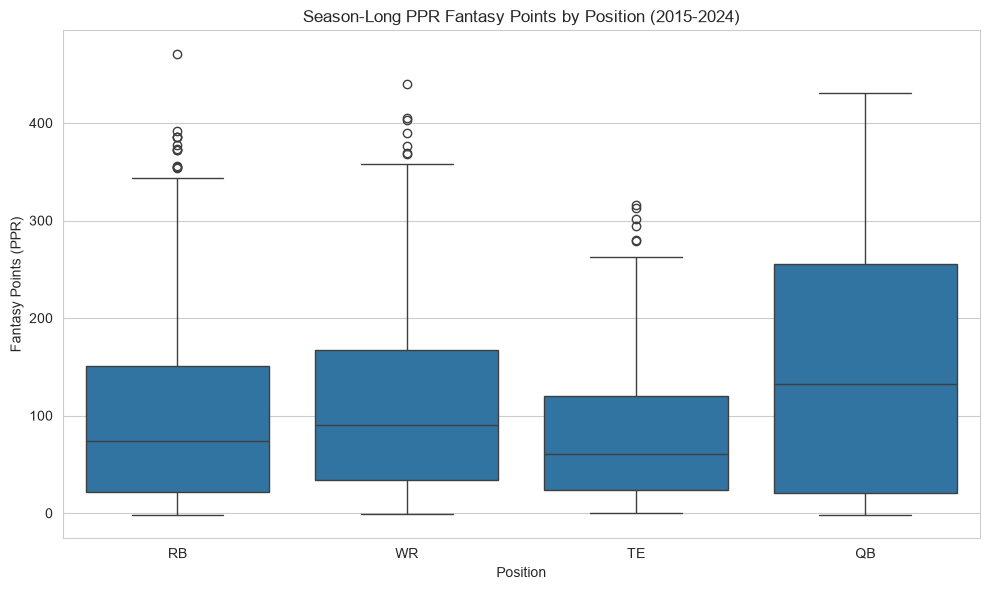

In [180]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=adp_with_outcomes, x='position', y='fantasy_points_ppr', ax=ax)
ax.set_title('Season-Long PPR Fantasy Points by Position (2015-2024)')
ax.set_xlabel('Position')
ax.set_ylabel('Fantasy Points (PPR)')
plt.tight_layout()
plt.show()


In [181]:
adp_with_outcomes.groupby('position')['fantasy_points_ppr'].describe()

,count,mean,std,min,25%,50%,75%,max
position,,,,,,,,
QB,563.0,144.733108,121.916347,-2.08,20.410,132.16,255.680,430.38
RB,1168.0,96.077243,86.865290,-2.00,21.600,74.05,151.175,471.20
TE,708.0,76.771751,65.001439,0.00,23.625,60.90,120.025,316.30
WR,1480.0,107.456014,85.848889,-0.80,34.350,90.10,167.105,439.50


## The core question: how well does ADP predict actual outcome?

We'll look at this two ways:
1. **Correlation** between `adp_avg` (lower = drafted earlier/more valuable)
   and `fantasy_points_ppr` (higher = better outcome) -- expect a strong
   negative correlation if ADP is doing its job.
2. **Visually**, via scatterplot, faceted by position since scoring scales
   differ a lot (QBs score much higher than the other positions).


In [182]:
from scipy.stats import spearmanr

for pos in ['QB', 'RB', 'WR', 'TE']:
    subset = adp_with_outcomes[adp_with_outcomes['position'] == pos].dropna(subset=['adp_avg', 'fantasy_points_ppr'])
    corr, pval = spearmanr(subset['adp_avg'], subset['fantasy_points_ppr'])
    print(f"{pos}: Spearman correlation (ADP avg vs PPR points) = {corr:.3f} (n={len(subset)}, p={pval:.2e})")


QB: Spearman correlation (ADP avg vs PPR points) = -0.781 (n=563, p=1.19e-116)
RB: Spearman correlation (ADP avg vs PPR points) = -0.703 (n=1168, p=1.71e-174)
WR: Spearman correlation (ADP avg vs PPR points) = -0.706 (n=1480, p=1.09e-223)
TE: Spearman correlation (ADP avg vs PPR points) = -0.682 (n=708, p=6.32e-98)


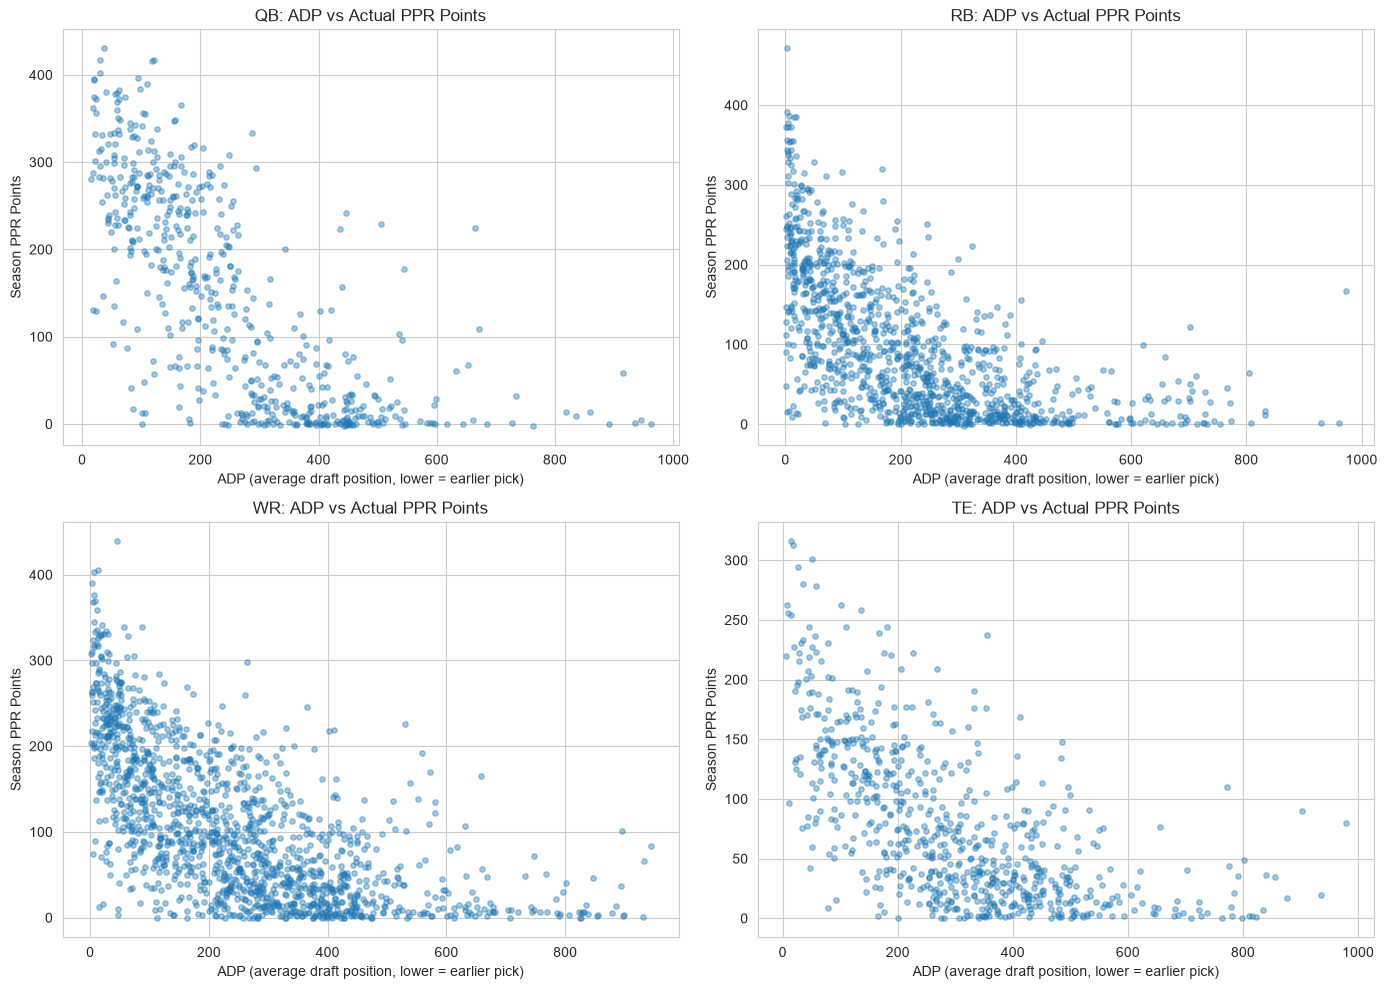

In [183]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
positions = ['QB', 'RB', 'WR', 'TE']

for ax, pos in zip(axes.flatten(), positions):
    subset = adp_with_outcomes[adp_with_outcomes['position'] == pos]
    ax.scatter(subset['adp_avg'], subset['fantasy_points_ppr'], alpha=0.4, s=15)
    ax.set_title(f'{pos}: ADP vs Actual PPR Points')
    ax.set_xlabel('ADP (average draft position, lower = earlier pick)')
    ax.set_ylabel('Season PPR Points')

plt.tight_layout()
plt.show()


## Observations (fill in after running the cells above)

- Negative correlation confirms ADP has *some* real predictive signal
  (as expected -- it's not random).
- The spread/scatter at any given ADP tier is the interesting part: this is
  literally the "bust and breakout" volatility the project is built around.
  A wide vertical spread at a given ADP means outcomes are unpredictable at
  that draft slot -- exactly where a better model could find an edge.
- Compare correlation strength across positions -- if e.g. RB shows weaker
  correlation than WR, that tells us RB is the position where ADP is least
  reliable, which has direct implications for draft strategy.
